# Deploy model and run inference

In [ ]:
# %%capture
# %pip install sagemaker -U

In [ ]:
# %pip install -q sagemaker boto3

In [3]:
%pip install -q opencv-python-headless
# %pip install -q tensorflow==2.16.1


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import glob
import cv2
import sagemaker
from sagemaker.tensorflow import TensorFlowModel
from sagemaker.utils import name_from_base
%matplotlib inline
import matplotlib.pyplot as plt
# import visualization_utils as viz_utils

In [5]:
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
bucket = sess.default_bucket()

print("Role:", role)
print("Bucket:", bucket)
print("Region:", sess.boto_region_name)



Role: arn:aws:iam::976369350238:role/service-role/AmazonSageMaker-ExecutionRole-20260113T202468
Bucket: sagemaker-us-east-1-976369350238
Region: us-east-1


Now that you have trained successfully your model, you want to look at the predictions on some sample images. To do so, you will need to find the s3 path of the exported model. You can navigate to the Training jobs section of the AWS web UI and click on the training job of interest. Scroll down and you should see something like this:

![Example Artifact](../data/example_artifact.png)

The model artifact path should look something like 
```s3://sagemaker-us-east-1-073338978050/tf2-object-detection-2022-10-22-21-26-37-033/output/model.tar.gz```. Use this value to update the `model_artifact` variable below.

In [6]:
!ls -lh model.tar.gz
!tar -tf model.tar.gz | head -n 30


-rw-rw-r-- 1 ec2-user ec2-user 101M Jan 14 04:32 model.tar.gz
./
./1/
./1/saved_model.pb
./1/assets/
./1/fingerprint.pb
./1/variables/
./1/variables/variables.index
./1/variables/variables.data-00000-of-00001


Now we can deploy the model. Run the following cell and check that the model was correctly deployed by navigating to Inference endpoints in the web UI.

![Example endpoint](../data/example_endpoints.png)


In [7]:
s3_model_uri = sess.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="udacity-od/faster-rcnn"
)
print("Uploaded model to:", s3_model_uri)


Uploaded model to: s3://sagemaker-us-east-1-976369350238/udacity-od/faster-rcnn/model.tar.gz


In [9]:
# TODO: Update the model artifact here. 
model_artifact = 's3://sagemaker-us-east-1-976369350238/udacity-od/faster-rcnn/model.tar.gz'

In [10]:
model = TensorFlowModel(
    name=name_from_base('tf2-object-detection'),
    model_data=model_artifact,
    role=role,
    framework_version='2.8'
)

predictor = model.deploy(initial_instance_count=1, instance_type='ml.g5.xlarge')

-----------!

In [11]:
import boto3

sm = boto3.client("sagemaker")
endpoints = sm.list_endpoints()["Endpoints"]
[end["EndpointName"] for end in endpoints]


['tf2-object-detection-2026-01-14-05-02-00-768']

In [12]:
# %%capture
%pip install -q --upgrade pillow imageio imageio-ffmpeg


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

endpoint_name = "tf2-object-detection-2026-01-14-05-02-00-768"

predictor = Predictor(endpoint_name=endpoint_name)
predictor.serializer = JSONSerializer()
predictor.deserializer = JSONDeserializer()


## Run inference

Our model is now deployed and we can query it. We are going to use the images available in `data/test_video` to run inference and generate a video. To do so, we are going to need a few tools:
* we need to sort all the frames by index order (which corresponds to chronological order)
* we need a function to load images into numpy array
* we need a loop to run inference and display the results on the input image

We list the frame paths and sort them by index.

In [13]:
frames_path = sorted(glob.glob('../data/test_video/*.png'), 
                     key = lambda k: int(os.path.basename(k).split('.')[0].split('_')[1]))

We create a small function to load images.

In [14]:
# import numpy as np
# def load_image(path: str) -> np.ndarray:
#     """Read an image from the path and returns a numpy array"""
#     cv_img = cv2.imread(path,1).astype('uint8')
#     cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
#     return cv_img

We create a mapping from id to name for visualization purposes.

In [ ]:
# def image_file_to_tensor(path):
#     cv_img = cv2.imread(path,1).astype('uint8')
#     cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
#     return cv_img

# images = []
# for idx, path in enumerate(frames_path):
#     if idx % 10 == 0:
#         print(f'Processed {idx}/{len(frames_path)} images.')
        
#     # load image
#     img = image_file_to_tensor(path)
#     inputs = {'instances': [img.tolist()]}
    
#     # run inference and extract results
#     detections = predictor.predict(inputs)['predictions'][0]
#     detection_boxes = np.array(detections['detection_boxes'])
#     detection_classes = [int(x) for x in detections['detection_classes']]
#     detection_scores = detections['detection_scores']
    
#     # display results on image
#     image_np_with_detections = \
#         viz_utils.visualize_boxes_and_labels_on_image_array(
#             img,
#             detection_boxes,
#             detection_classes,
#             detection_scores,
#             category_index,
#             use_normalized_coordinates=True,
#             max_boxes_to_draw=100,
#             min_score_thresh=0.6,
#             agnostic_mode=False)
#     images.append(image_np_with_detections)

In [30]:
import numpy as np
from PIL import *
import json


def load_image(path: str) -> np.ndarray:
    """Load an image as an RGB uint8 numpy array."""
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.uint8)

def draw_detections(
    image_np: np.ndarray,
    boxes: np.ndarray,
    classes: np.ndarray,
    scores: np.ndarray,
    category_index: dict,
    min_score: float = 0.30,
    line_width: int = 3,
) -> np.ndarray:
    """Draw boxes + labels on an RGB image (numpy array) and return a new numpy array."""
    img = Image.fromarray(image_np)
    draw = ImageDraw.Draw(img)

    h, w = image_np.shape[0], image_np.shape[1]

    for box, cls, score in zip(boxes, classes, scores):
        if score < min_score:
            continue

        # box is normalized ymin, xmin, ymax, xmax
        ymin, xmin, ymax, xmax = box
        left, top, right, bottom = int(xmin * w), int(ymin * h), int(xmax * w), int(ymax * h)

        # Basic bounds check
        left, top = max(0, left), max(0, top)
        right, bottom = min(w - 1, right), min(h - 1, bottom)

        draw.rectangle([left, top, right, bottom], outline="lime", width=line_width)

        name = category_index.get(int(cls), {}).get("name", str(int(cls)))
        label = f"{name}: {score:.2f}"

        # Text background
        text_w, text_h = draw.textbbox((0, 0), label)[2:]
        pad = 2
        draw.rectangle([left, top - text_h - 2*pad, left + text_w + 2*pad, top], fill="black")
        draw.text((left + pad, top - text_h - pad), label, fill="white")

    return np.array(img, dtype=np.uint8)


In [31]:
category_index = {
                    1: {'id': 1, 'name': 'vehicle'}, 
                    2: {'id': 2, 'name': 'pedestrian'},
                    4: {'id': 4, 'name': 'cyclist'}
                }

This is the main loop:
* we load images to numpy
* we query the deployed model
* we display the inference results on the images

We can verify that the model worked correctly by displaying elements of the `images` list.

[1/100] Wrote inference_output/frame_0.png
[11/100] Wrote inference_output/frame_10.png
[21/100] Wrote inference_output/frame_20.png
[31/100] Wrote inference_output/frame_30.png
[41/100] Wrote inference_output/frame_40.png
[51/100] Wrote inference_output/frame_50.png
[61/100] Wrote inference_output/frame_60.png
[71/100] Wrote inference_output/frame_70.png
[81/100] Wrote inference_output/frame_80.png
[91/100] Wrote inference_output/frame_90.png
Done. Annotated frames saved to: inference_output


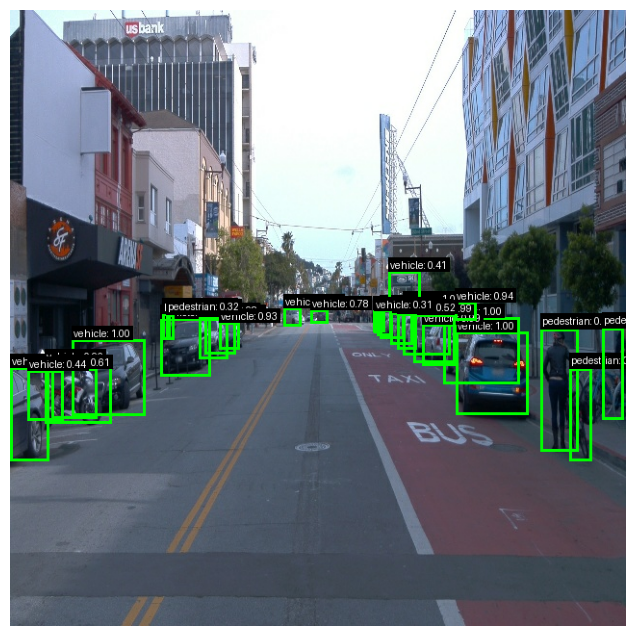

In [32]:
# Run inference on all frames and save annotated outputs locally

output_dir = "inference_output"
os.makedirs(output_dir, exist_ok=True)

annotated_frames = []

for i, frame_path in enumerate(frames_path):
    img_np = load_image(frame_path)

    # SageMaker TF Serving expects JSON with instances
    # payload = json.dumps({"instances": [img_np.tolist()]})
    # prediction = predictor.predict(payload)

    payload = {"instances": [{"input_tensor": img_np.tolist()}]}
    prediction = predictor.predict(payload)


    # TF Serving returns a list of predictions; take the first (single image)
    pred = prediction["predictions"][0]

    boxes = np.array(pred["detection_boxes"], dtype=np.float32)
    scores = np.array(pred["detection_scores"], dtype=np.float32)
    classes = np.array(pred["detection_classes"], dtype=np.int32)

    # Some models also return num_detections; handle if present
    if "num_detections" in pred:
        n = int(pred["num_detections"])
        boxes, scores, classes = boxes[:n], scores[:n], classes[:n]

    annotated = draw_detections(
        img_np,
        boxes=boxes,
        classes=classes,
        scores=scores,
        category_index=category_index,
        min_score=0.30,
        line_width=3,
    )

    out_path = os.path.join(output_dir, os.path.basename(frame_path))
    Image.fromarray(annotated).save(out_path)

    annotated_frames.append(annotated)

    if i % 10 == 0:
        print(f"[{i+1}/{len(frames_path)}] Wrote {out_path}")

print("Done. Annotated frames saved to:", output_dir)

# Preview one example
plt.figure(figsize=(14, 8))
plt.imshow(annotated_frames[min(0, len(annotated_frames)-1)])
plt.axis("off")
plt.show()


Finally, we can create a video (`output.avi`) with our detections by running the following function.

In [37]:
# Create an MP4 from the annotated frames
# If this fails due to missing ffmpeg, re-run the first cell (it installs imageio-ffmpeg).
import imageio

fps = 10
video_out = "output.mp4"

writer = imageio.get_writer(video_out, fps=fps)
for frame in annotated_frames:
    writer.append_data(frame)
writer.close()

print("Wrote video:", video_out)


Wrote video: output.mp4


In [ ]:
# frame_width = images[0].shape[0]
# frame_height = images[0].shape[1]

# out = cv2.VideoWriter('output.avi', cv2.VideoWriter_fourcc('M','J','P','G'), 10, (frame_width,frame_height))

# # Read and display the images
# for image in images:
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     out.write(image) # Write the image to the video
#     if cv2.waitKey(1) == ord('q'): # Hit `q` to exit
#         break
        
# # Release everything if job is finished
# out.release()
# cv2.destroyAllWindows()

The video would be stored in the current working directory. You can download it from Sagemaker and run it locally.